In [46]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

In [ ]:
#read csv file 
df = pd.read_csv('spam.csv', encoding='latin1')

In [30]:
# review data rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
#change column names and map labels
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.columns = ['type', 'sms']
df['type'] = df['type'].map({'ham': 0, 'spam': 1})

In [32]:
#preprocess text data
# explain each step of the preprocess_text function with comments
import re
def preprocess_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    # Replace URLs with ' url '
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    # Replace digits with ' num '
    text = re.sub(r'\d+', ' num ', text)
    # Replace non-alphabetic characters with a space
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text 

df['sms'] = df['sms'].apply(preprocess_text)

# Remove rows where sms became empty after preprocessing (e.g. messages with only symbols like ':)')
df = df[df['sms'] != '']
df = df.reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

Remaining rows: 5570


In [34]:
# save the cleaned dataset to a new csv file
df.to_csv('spam_cleaned.csv', index=False)

In [36]:
# give the summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   type    5570 non-null   int64
 1   sms     5570 non-null   str  
dtypes: int64(1), str(1)
memory usage: 87.2 KB


In [37]:
# ── 1. Basic statistics ──────────────────────────────────────────────────────
total = len(df)
counts = df['type'].value_counts().rename({0: 'ham', 1: 'spam'})
print(f"Total messages : {total}")
print(f"Ham            : {counts['ham']} ({counts['ham']/total*100:.1f}%)")
print(f"Spam           : {counts['spam']} ({counts['spam']/total*100:.1f}%)")
print(f"Imbalance ratio: {counts['ham']/counts['spam']:.1f}:1  (ham:spam)")

Total messages : 5570
Ham            : 4823 (86.6%)
Spam           : 747 (13.4%)
Imbalance ratio: 6.5:1  (ham:spam)


In [38]:
# ── 2. SMS length analysis (word count) ──────────────────────────────────────
df['word_count'] = df['sms'].apply(lambda x: len(x.split()))

stats = df.groupby('type')['word_count'].agg(['mean', 'min', 'max']).rename(index={0: 'ham', 1: 'spam'})
stats.columns = ['mean', 'min', 'max']
print("Word count statistics per class:")
print(stats.round(1))

Word count statistics per class:
      mean  min  max
type                
ham   14.1    1  171
spam  26.0    2   38


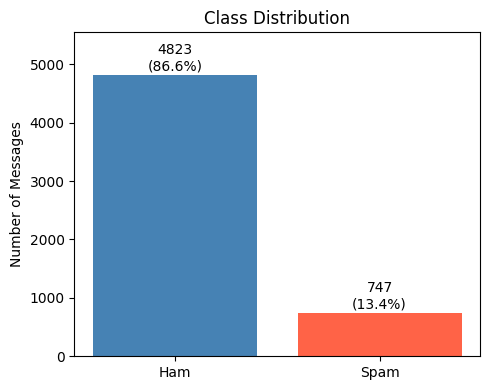

In [42]:
# ── 3. Class distribution bar chart ──────────────────────────────────────────
labels = ['Ham', 'Spam']
values = [counts['ham'], counts['spam']]
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution')
ax.set_ylabel('Number of Messages')
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

/var/folders/l0/ptpkl4s915j4hyfjcgrjw40c0000gn/T/ipykernel_65094/1458963308.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ham_wc, spam_wc], labels=['Ham', 'Spam'],


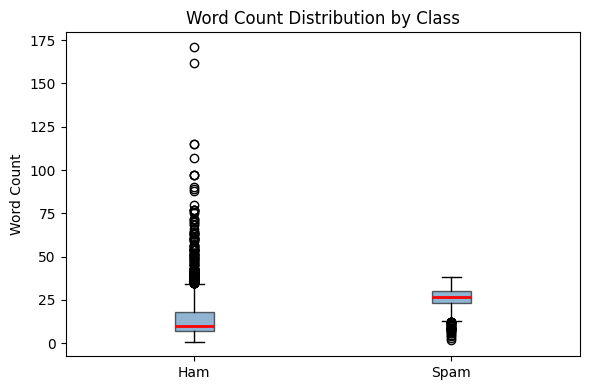

In [43]:
# ── 4. Word count distribution – boxplot (ham vs spam) ───────────────────────
ham_wc  = df[df['type'] == 0]['word_count']
spam_wc = df[df['type'] == 1]['word_count']

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([ham_wc, spam_wc], labels=['Ham', 'Spam'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Word Count Distribution by Class')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.show()

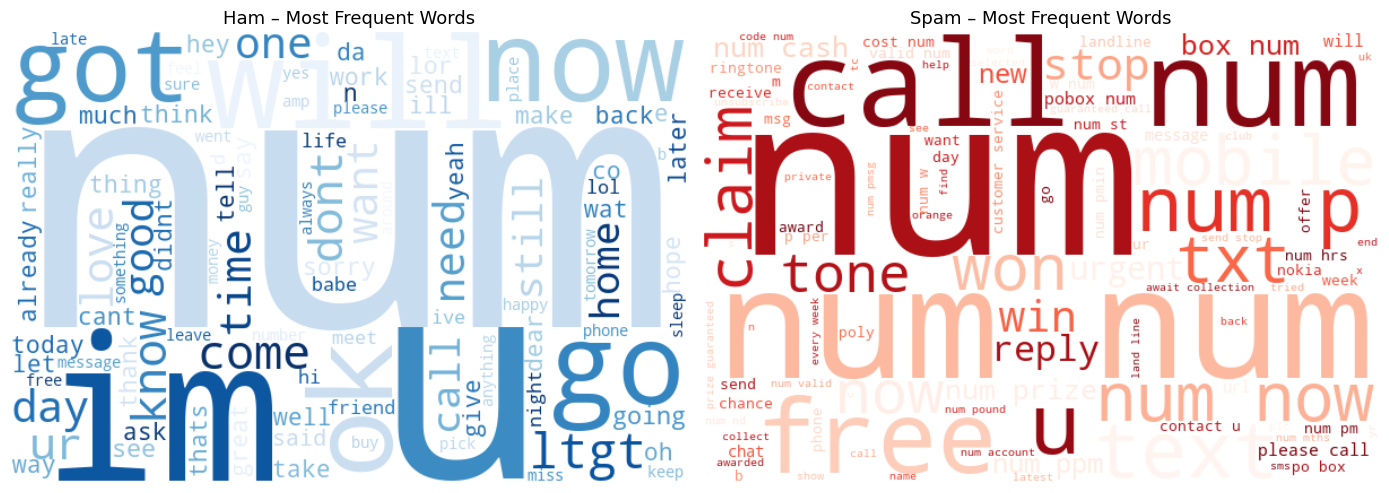

In [47]:
# ── 5. Word clouds ────────────────────────────────────────────────────────────
ham_text  = ' '.join(df[df['type'] == 0]['sms'])
spam_text = ' '.join(df[df['type'] == 1]['sms'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, color in zip(axes,
                                   [ham_text, spam_text],
                                   ['Ham', 'Spam'],
                                   ['Blues', 'Reds']):
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{title} – Most Frequent Words', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# ── 6. Sample messages ───────────────────────────────────────────────────────
print("=== Sample Ham Messages ===")
print(df[df['type'] == 0]['sms'].sample(3, random_state=42).to_string(index=False))
print("\n=== Sample Spam Messages ===")
print(df[df['type'] == 1]['sms'].sample(3, random_state=42).to_string(index=False))

=== Sample Ham Messages ===
                              nokia phone is lovly
hey we can go jazz power yoga hip hop kb and yo...
                 will b going to esplanade fr home

=== Sample Spam Messages ===
summers finally here fancy a chat or flirt with...
this is the num nd time we have tried num conta...
get ur num st ringtone free now reply to this m...
